In [1]:

import os
import importlib
from pathlib import Path

import pandas as pd
import numpy as np

import inframind_proteus.outbreak_dynamics
from inframind_proteus.outbreak_dynamics.sampling import sample_lhs

importlib.reload(inframind_proteus.outbreak_dynamics)
from inframind_proteus.outbreak_dynamics import (
    SimulationConfig, RenewalSimulator, SimulationOutput,
    LogisticRT, ConstantGammaGT, build_calibration_params_df,
    build_initial_infec_df
)

from inframind_proteus.outbreak_dynamics.utils import (
    load_yaml_dict,
)

# os.chdir("..")
# print(os.getcwd())

## Single-cell test run

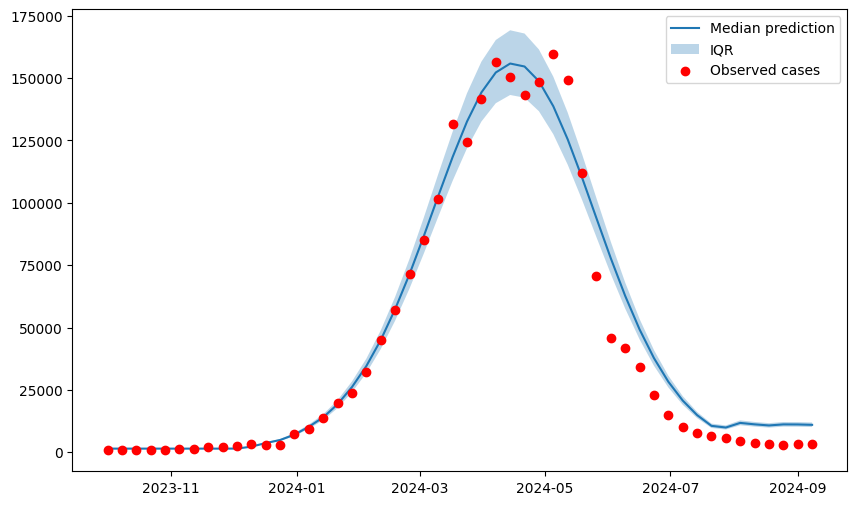

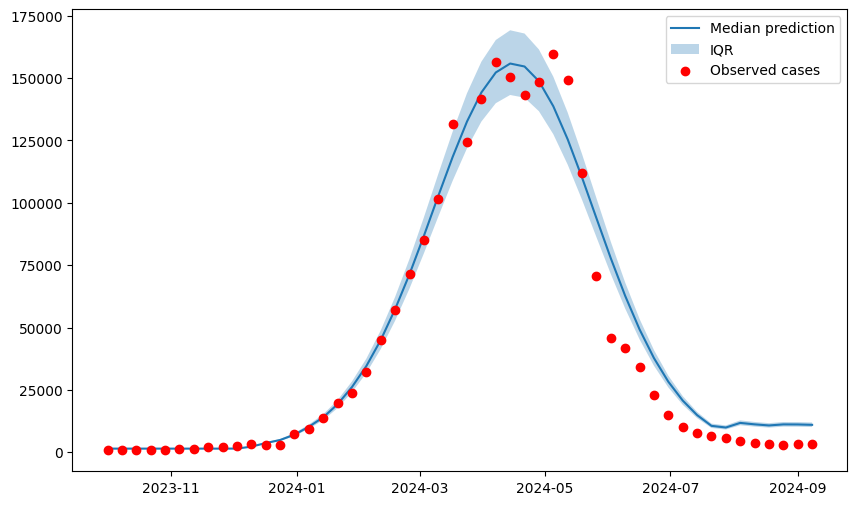

In [7]:
# --- Observation data
uf = "SP"
tgt_data_df = pd.read_csv(
    f"../.local/dengue/cases_tseries_{uf}.csv",
    parse_dates=["date"]
)
sr = tgt_data_df.set_index("date")["casos"]
observations_sr = sr   # -()-

# --- Simulation setup
config_dict = load_yaml_dict(Path("../configs/outbreak_dynamics_example.yaml"))
simulator = RenewalSimulator.from_config_dict(config_dict)

# Override desired configurations
config = simulator.config
config.mode = "calibration"
config.num_simulations = 10000

# --- Build auxiliary data frames for simulations
params_df = build_calibration_params_df(config.num_simulations, config.sampling)
initial_infec_df = build_initial_infec_df(
    config.num_simulations, simulator._gt_max_steps, config.temporal.step_dt,
    config.initial_infections
)

# --- Run simulations (calibration mode)
results = simulator.run(
    params_df=params_df,
    initial_infec_df=initial_infec_df,
    observations_sr=observations_sr,
)


# --------------

# --- Select best simulation (using WIS score)
best_i_simulation = results.wis_array.sum(axis=1).argmin()
best_beam_df = results.case_beam_df.xs(best_i_simulation, level="i_simulation").T
df = pd.concat([observations_sr, best_beam_df], axis=1)
df = df.loc[~df[0.5].isna()]
df.index.name = "date"

# Visualize the best simulation cases beam against observed cases
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df.index, df[0.5], label="Median prediction")
ax.fill_between(df.index, df[0.25], df[0.75], alpha=0.3, label="IQR")
ax.scatter(df.index, df["casos"], color="red", label="Observed cases", zorder=5)
ax.legend()
fig


# Draft-tests

In [5]:

# simulator = RenewalSimulator(
#     rt_model=LogisticRT(),
#     gt_model=ConstantGammaGT(
#         shape=10.,
#         scale=1.8,
#     ),
#     config=SimulationConfig(
#
#     )
# )

config_dict = load_yaml_dict(Path("../configs/outbreak_dynamics_example.yaml"))

simulator = RenewalSimulator.from_config_dict(
    config_dict = config_dict,
    # rt_model=LogisticRT(),
    # gt_model=ConstantGammaGT(
    #     shape=10.,
    #     scale=1.8,
    # ),
)

simulator

initial_infec_df = pd.DataFrame(
    {
        t: np.ones(config.num_simulations) for t in range(0, simulator._gt_max_steps * simulator._step_dt, simulator._step_dt)
    }
)

# simulator.config.temporal.sim_start

In [6]:
config = simulator.config

# config.temporal.calibration_start = pd.Timestamp("2023-10-01")
# config.temporal.calibration_end =   pd.Timestamp("2023-12-31")
config.num_simulations = 100000
# config.sampling.num_simulations

# params_df = pd.DataFrame(
#     {
#         # Generation time
#         "gt_gamma_shape":10.0,
#         "gt_gamma_scale": 1.8,  # Expectancy = product
#
#         # R(t) stepped logistic function
#         "rt_logist_width": 13.,  # In days
#         "rt_logist_center": 100.,  # In days
#         "rt_logist_roff": 1.0,  # Off-season R value (before start)
#         "rt_logist_start": 50.,
#         "rt_logist_rmin": 0.2,  # Post-outbreak baseline
#         "rt_logist_rmax": 1.6,  # Essentially "R0"
#         "rt_logist_end": 300.,
#
#         # Infection-to-notification model
#         "notif_nb_overdispersion": 10.,
#         "notif_scaling_factor": 1.0,  # Only applied if using external factor
#     },
#     index=range(config.num_simulations)
# )
#
# # # Override with LHS
# # from
# params_df["rt_logist_rmax"] = np.linspace(0.9, 2.5, config.num_simulations)
#
# # Parameters to be explored
# lhs_param_ranges = {
#     "rt_logist_width": [1, 80],
#     "rt_logist_center": [10, 280],
#     "rt_logist_rmax": [1.1, 4.0],
#     "notif_nb_overdispersion": [0.1, 100],
#     "notif_scaling_factor": [10, 5000],
# }

# # Override sampled values in params_table_df
# rng = np.random.default_rng(seed=42)
# lhs_scaled_df = sample_lhs(lhs_param_ranges, config.num_simulations, rng)
# for col in lhs_scaled_df.columns:
#     params_df[col] = lhs_scaled_df[col]

# calibration_sampling_config = parse_calibration_sampling_config(config_dict)
# required_param_names = [
#     "gt_gamma_shape",
#     "gt_gamma_scale",
#     "rt_logist_width",
#     "rt_logist_center",
#     "rt_logist_roff",
#     "rt_logist_start",
#     "rt_logist_rmin",
#     "rt_logist_rmax",
#     "rt_logist_end",
#     "notif_nb_overdispersion",
#     "notif_scaling_factor",
# ]
params_df = build_calibration_params_df(config.num_simulations, config.sampling)#, required_param_names)

params_df

initial_infec_df = pd.DataFrame(
    {
        t: np.ones(config.num_simulations) for t in range(0, simulator._gt_max_steps * simulator._step_dt, simulator._step_dt)
    }
)

# --- Observation data
uf = "SP"
tgt_data_df = pd.read_csv(
    f"../.local/dengue/cases_tseries_{uf}.csv",
    parse_dates=["date"]
)
sr = tgt_data_df.set_index("date")["casos"]
date_start = config.temporal.calibration_start
date_end = date_start + pd.Timedelta(weeks=config.num_time_steps + 2)  # Add some buffer to ensure we have enough
sr = sr#.loc[date_start:date_end - pd.Timedelta(days=1)]  # Inclusive end, so subtract one day
# observations_sr = sr.reset_index(drop=True)  # -()-
observations_sr = sr   # -()-

config.mode = "calibration"
# config.mode = "projection"

results = simulator.run(
    params_df=params_df,
    initial_infec_df=initial_infec_df,
    observations_sr=observations_sr,
)
params_df

results

SimulationOutput(infec_df=t             2023-10-01  2023-10-08  2023-10-15  2023-10-22  2023-10-29  \
i_simulation                                                               
0                0.99995     0.99995    0.999938    0.999914      0.9999   
1                0.99995     0.99995    0.999938    0.999914      0.9999   
2                0.99995     0.99995    0.999938    0.999914      0.9999   
3                0.99995     0.99995    0.999938    0.999914      0.9999   
4                0.99995     0.99995    0.999938    0.999914      0.9999   
...                  ...         ...         ...         ...         ...   
99995            0.99995     0.99995    0.999938    0.999914      0.9999   
99996            0.99995     0.99995    0.999938    0.999914      0.9999   
99997            0.99995     0.99995    0.999938    0.999914      0.9999   
99998            0.99995     0.99995    0.999938    0.999914      0.9999   
99999            0.99995     0.99995    0.999938    0.999914  

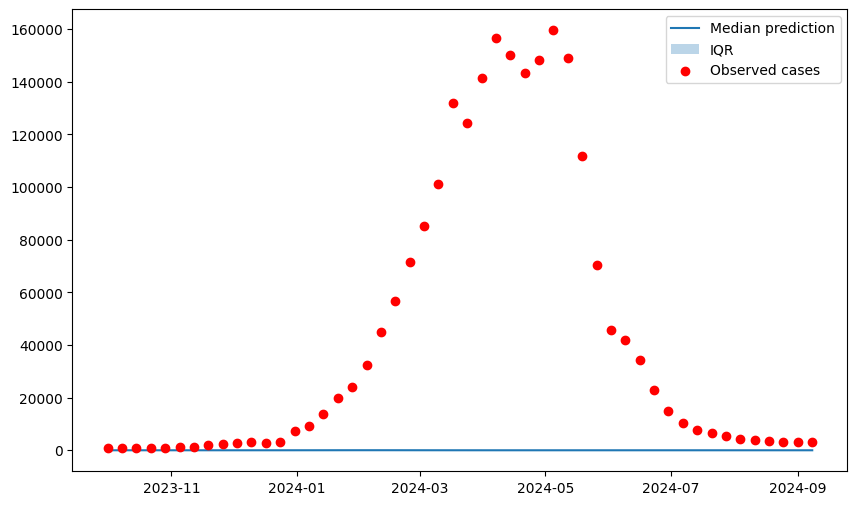

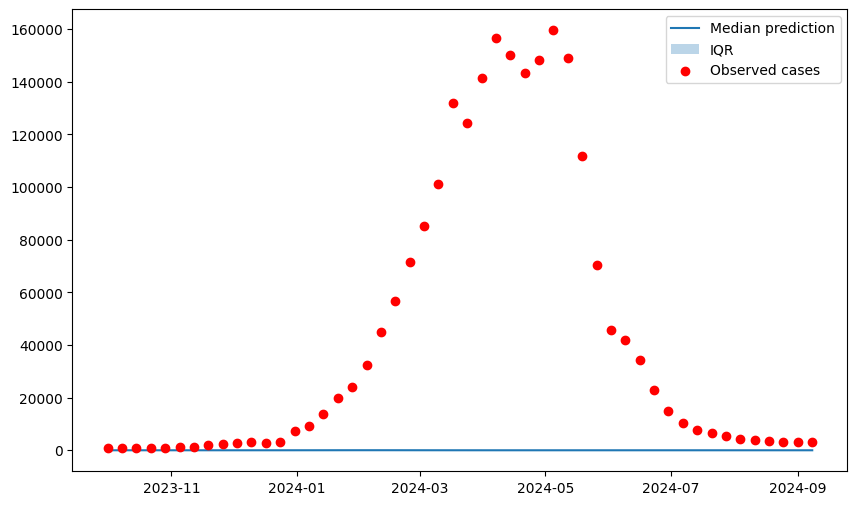

In [7]:
best_i_simulation = results.wis_array.sum(axis=1).argmin()


best_beam_df = results.case_beam_df.xs(best_i_simulation, level="i_simulation").T
observations_sr

df = pd.concat([observations_sr, best_beam_df], axis=1)
df = df.loc[~df[0.5].isna()]
df.index.name = "date"

# ----
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))


ax.plot(df.index, df[0.5], label="Median prediction")
ax.fill_between(df.index, df[0.25], df[0.75], alpha=0.3, label="IQR")
ax.scatter(df.index, df["casos"], color="red", label="Observed cases", zorder=5)

ax.legend()
fig
# fig

In [5]:
# np.array([1, 3, 4]) >= pd.Timestamp("2023-10-02")
np.array([pd.Timestamp("2023-10-02"), pd.Timestamp("2023-10-04")]) >= pd.Timestamp("2023-10-02")

array([ True,  True])